In [1]:
import numpy as np
import torch
from src.raindrop_surrogate.utils import load_config
from scripts.predict import load_or_compute_stats, predict_single_ship, RadialAcousticSurrogate

In [ ]:
# Load the config
cfg = load_config("configs/default.yaml")

# Load scaling stats or compute and save them if not available.
stats = load_or_compute_stats(cfg)

# Get cached bathymetry grid
bathy_grid = np.load("cache/bathy_aligned_256.npy")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Quick model setup
model = RadialAcousticSurrogate(bathy_latent=128, ais_latent=64, crop_size=256).to(device).eval()

# Load the saved model
checkpoint = torch.load(cfg.evaluation.checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])


<All keys matched successfully>

In [9]:
# example ship data
# AIS data: [lat, lon, speed, ship type, length]
ship_data = [38.5, -27.5, 17, 36, 155.0]

# Predict the SPL field for a single example using the appropriate function
spl_pred = predict_single_ship(model, stats, ship_data, bathy_grid, device=device)

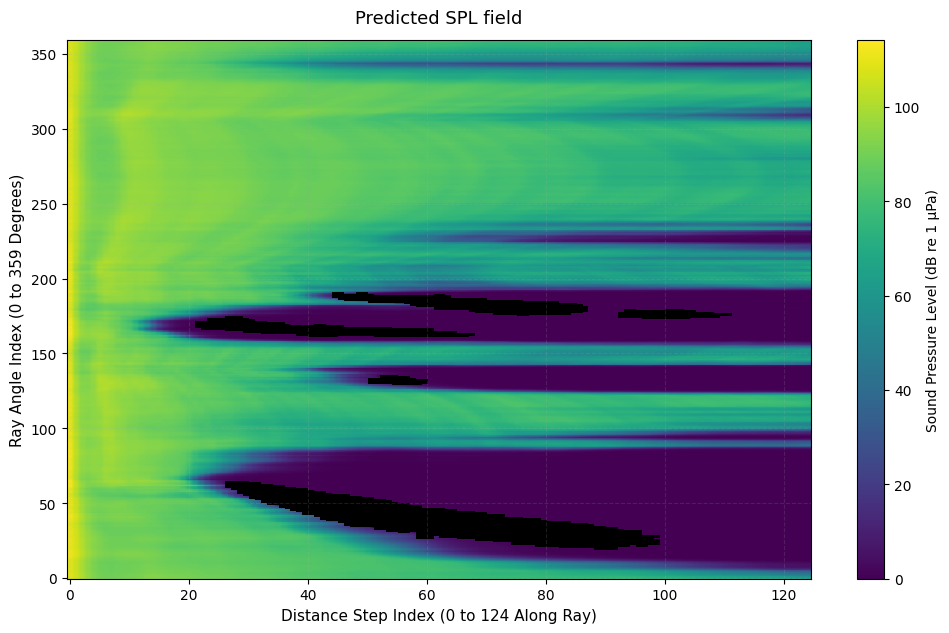

In [10]:
from raindrop_surrogate.visualize import plot_predicted_spl_radial


ship_lat = ship_data[0]
ship_lon = ship_data[1]
spatial_meta = stats["spatial_grid"]



# Visualize the predicted SPL 
plot_predicted_spl_radial(
    radial_output=spl_pred,
    spatial_meta=spatial_meta,
    ship_lat=ship_lat,
    ship_lon=ship_lon
)


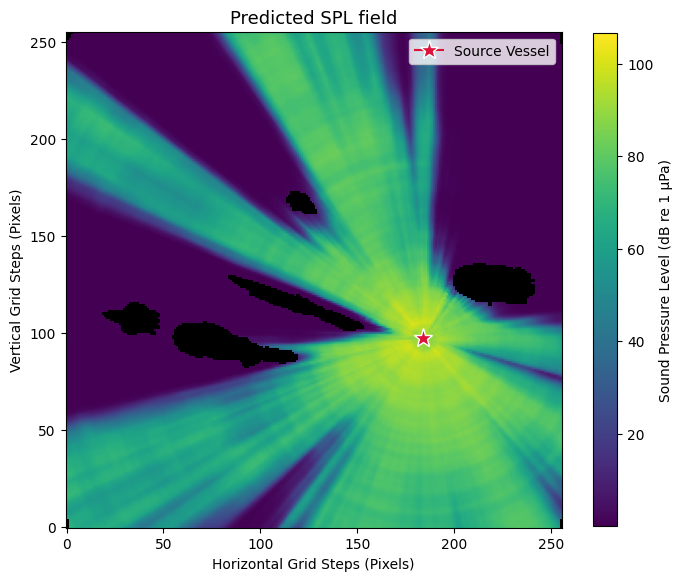

In [11]:
# Visualize the predicted SPL field in cartesian coordinates
from raindrop_surrogate.visualize import plot_predicted_spl_cartesian


plot_predicted_spl_cartesian(
    radial_output=spl_pred,
    spatial_meta=spatial_meta,
    ship_lat=ship_lat,
    ship_lon=ship_lon
)
